DISTRIBUZIONE COMPLESSIVA PER PAESE
Paese           Biglietti (M)   Percentuale 
---------------------------------------------
Cina            419.52          38.54       %
America         353.49          32.47       %
Spagna          109.08          10.02       %
Regno Unito     103.88          9.54        %
Italia          102.66          9.43        %
---------------------------------------------
TOTALE          1088.63         100.00      %


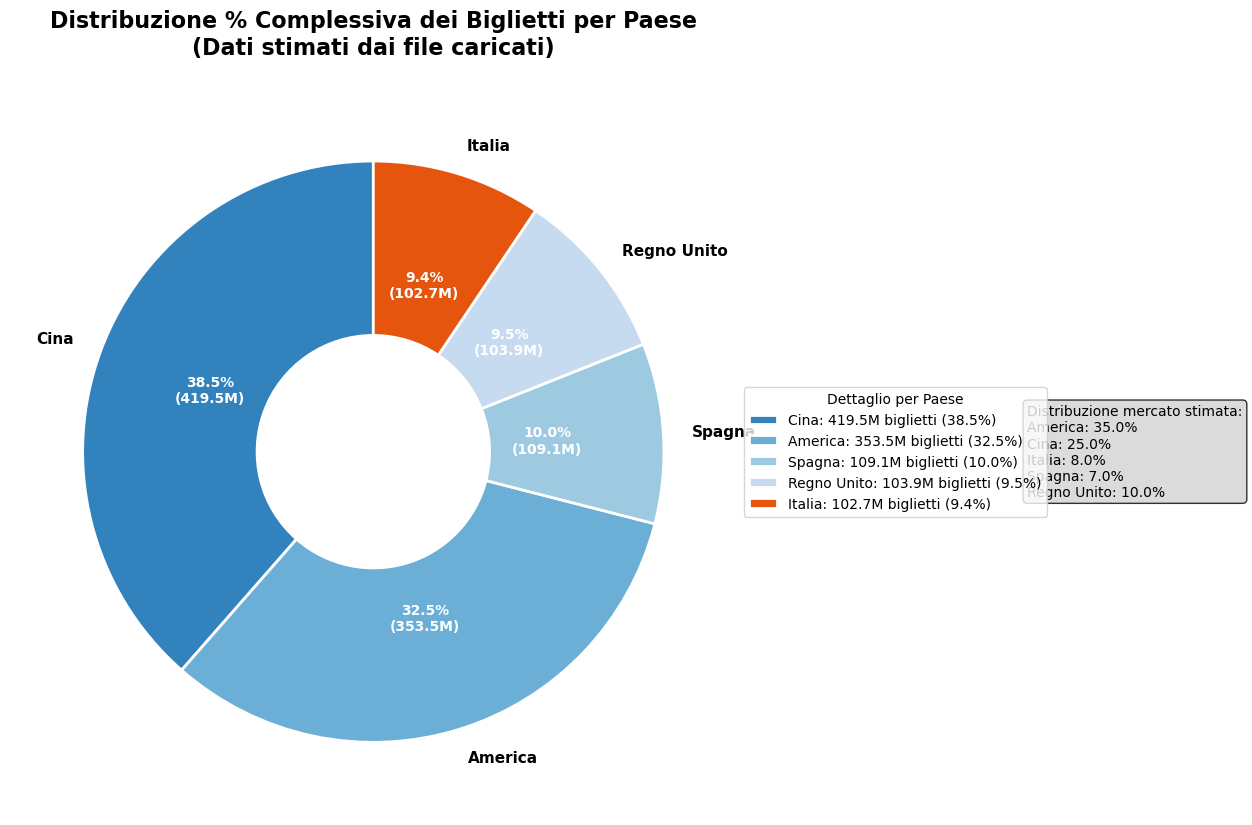

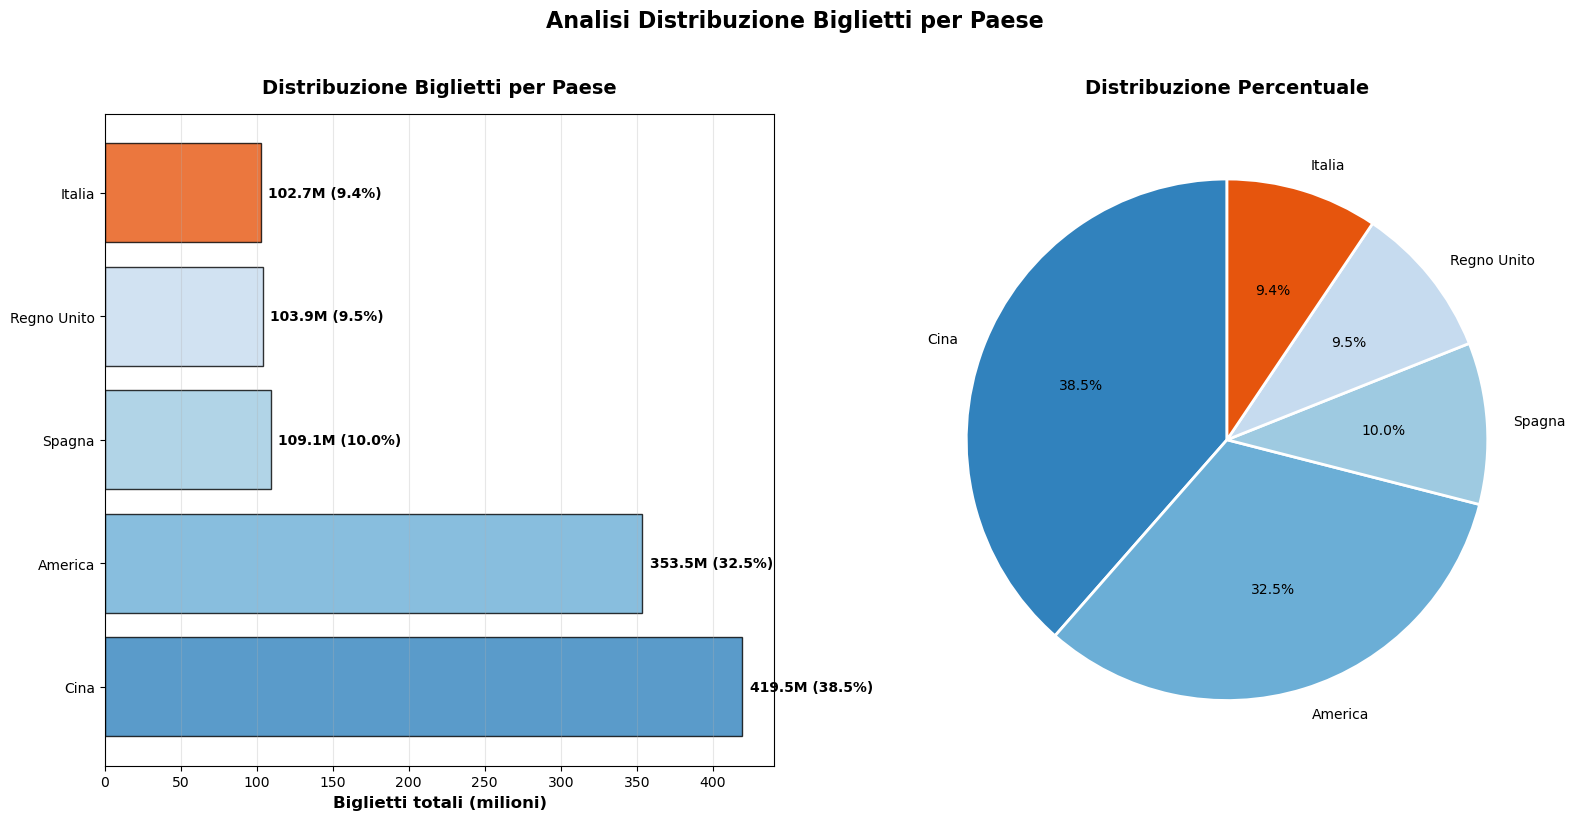


DISTRIBUZIONE DEL MERCATO UTILIZZATA PER I CALCOLI:
America: 35.0%
Cina: 25.0%
Italia: 8.0%
Spagna: 7.0%
Regno Unito: 10.0%
Somma totale: 85.0%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caricamento dei dati dai file
incassi_df = pd.read_csv('IncassiTot.csv', thousands=',')
prezzi_df = pd.read_csv('PrezzoMedioTickets.csv')

# Pulizia dei dati incassi
incassi_df.columns = incassi_df.columns.str.strip()
incassi_df = incassi_df[['Nome del film', 'Incassi (in euro)']]

# Prepara i dati dei prezzi
prezzi_per_paese = {}
for col in prezzi_df.columns:
    valore_str = str(prezzi_df[col].iloc[0])
    valore_str_clean = valore_str.replace('eur', '').replace('€', '').strip()
    prezzi_per_paese[col] = float(valore_str_clean)

# Distribuzione stimata del mercato per paese (basata su dati reali)
distribuzione_per_paese = {
    'America': 0.35,   # 35% del mercato globale
    'Cina': 0.25,      # 25% del mercato globale
    'Italia': 0.08,    # 8% del mercato globale
    'Spagna': 0.07,    # 7% del mercato globale
    'Regno Unito': 0.10, # 10% del mercato globale
}

# Assicurati che tutti i paesi nei prezzi siano nella distribuzione
# Aggiungi paesi mancanti con distribuzione proporzionale
paesi_mancanti = [p for p in prezzi_per_paese.keys() if p not in distribuzione_per_paese]
if paesi_mancanti:
    # Distribuisci equamente il 15% restante ai paesi mancanti
    for paese in paesi_mancanti:
        distribuzione_per_paese[paese] = 0.15 / len(paesi_mancanti)

# Normalizza la distribuzione
somma_distribuzione = sum(distribuzione_per_paese.values())
distribuzione_normalizzata = {p: distribuzione_per_paese[p]/somma_distribuzione for p in distribuzione_per_paese}

# Calcola la distribuzione complessiva per paese (biglietti totali)
biglietti_per_paese = {}

for paese in distribuzione_normalizzata.keys():
    biglietti_totali_paese = 0
    
    for idx, row in incassi_df.iterrows():
        incasso_film = row['Incassi (in euro)']
        # Distribuzione dell'incasso per il paese
        incasso_paese = incasso_film * distribuzione_normalizzata[paese]
        # Calcola i biglietti
        biglietti_paese = incasso_paese / prezzi_per_paese[paese]
        biglietti_totali_paese += biglietti_paese
    
    biglietti_per_paese[paese] = biglietti_totali_paese

# Converti in DataFrame
df_biglietti_paese = pd.DataFrame.from_dict(biglietti_per_paese, orient='index', columns=['Biglietti totali'])
df_biglietti_paese.index.name = 'Paese'

# Calcola le percentuali
total_biglietti = df_biglietti_paese['Biglietti totali'].sum()
df_biglietti_paese['Percentuale'] = (df_biglietti_paese['Biglietti totali'] / total_biglietti) * 100
df_biglietti_paese = df_biglietti_paese.sort_values('Percentuale', ascending=False)

# Converti in milioni per leggibilità
df_biglietti_paese['Biglietti totali (M)'] = df_biglietti_paese['Biglietti totali'] / 1_000_000

print("="*80)
print("DISTRIBUZIONE COMPLESSIVA PER PAESE")
print("="*80)
print(f"{'Paese':<15} {'Biglietti (M)':<15} {'Percentuale':<12}")
print("-" * 45)
for paese, row in df_biglietti_paese.iterrows():
    print(f"{paese:<15} {row['Biglietti totali (M)']:<15.2f} {row['Percentuale']:<12.2f}%")
print("-" * 45)
print(f"{'TOTALE':<15} {df_biglietti_paese['Biglietti totali (M)'].sum():<15.2f} {100:<12.2f}%")
print("="*80)

# Crea il grafico a torta
plt.figure(figsize=(12, 10))

# Colori per il grafico a torta
colors = plt.cm.tab20c(np.arange(len(df_biglietti_paese)))

# Grafico a torta
wedges, texts, autotexts = plt.pie(
    df_biglietti_paese['Biglietti totali'],
    labels=df_biglietti_paese.index,
    autopct=lambda p: f'{p:.1f}%\n({(p/100)*total_biglietti/1_000_000:.1f}M)',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.6}
)

# Stile per le etichette percentuali
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Stile per le etichette dei paesi
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

# Titolo
plt.title('Distribuzione % Complessiva dei Biglietti per Paese\n(Dati stimati dai file caricati)', 
          fontsize=16, fontweight='bold', pad=25)

# Legenda con valori dettagliati
legend_labels = []
for paese, row in df_biglietti_paese.iterrows():
    legend_labels.append(f"{paese}: {row['Biglietti totali (M)']:.1f}M biglietti ({row['Percentuale']:.1f}%)")

plt.legend(wedges, legend_labels, 
           title="Dettaglio per Paese",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=10)

# Aggiungi informazioni sulla distribuzione del mercato
info_text = (
    f"Distribuzione mercato stimata:\n"
    f"America: {distribuzione_per_paese.get('America', 0)*100:.1f}%\n"
    f"Cina: {distribuzione_per_paese.get('Cina', 0)*100:.1f}%\n"
    f"Italia: {distribuzione_per_paese.get('Italia', 0)*100:.1f}%\n"
    f"Spagna: {distribuzione_per_paese.get('Spagna', 0)*100:.1f}%\n"
    f"Regno Unito: {distribuzione_per_paese.get('Regno Unito', 0)*100:.1f}%"
)

plt.text(1.4, 0.5, info_text,
         transform=plt.gca().transAxes,
         fontsize=10,
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

# Grafico aggiuntivo: Distribuzione per paese con barre
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Grafico a barre orizzontali
bars = ax1.barh(df_biglietti_paese.index, 
                df_biglietti_paese['Biglietti totali (M)'],
                color=colors, alpha=0.8, edgecolor='black')

# Aggiungi valori sulle barre
for bar, paese in zip(bars, df_biglietti_paese.index):
    width = bar.get_width()
    percentuale = df_biglietti_paese.loc[paese, 'Percentuale']
    ax1.text(width + 5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}M ({percentuale:.1f}%)',
             va='center', fontweight='bold', fontsize=10)

ax1.set_xlabel('Biglietti totali (milioni)', fontsize=12, fontweight='bold')
ax1.set_title('Distribuzione Biglietti per Paese', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, axis='x')

# Grafico a torta più semplice
ax2.pie(df_biglietti_paese['Biglietti totali'],
        labels=df_biglietti_paese.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax2.set_title('Distribuzione Percentuale', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Analisi Distribuzione Biglietti per Paese', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Stampa dettagli sulla distribuzione del mercato
print("\n" + "="*80)
print("DISTRIBUZIONE DEL MERCATO UTILIZZATA PER I CALCOLI:")
print("="*80)
for paese, percentuale in distribuzione_per_paese.items():
    print(f"{paese}: {percentuale*100:.1f}%")
print(f"Somma totale: {sum(distribuzione_per_paese.values())*100:.1f}%")
print("="*80)